In [1]:
import copy
import numpy as np
import pickle

In [2]:
from plant_model import GroupOfElectrolysers
from reference_trajectrory_source_model import ReferenceTrajectorySource
from controller_model import Controller
from control_assessment_model import ControlAssessment

In [3]:
from controller_NeuroEvolutional import Agent
# from controller_NeuroEvolutional_2elec import Agent as Agent_2elec

In [4]:
from controller_MPC import MPC

In [5]:
from controller_heuristic import ControllerHeuristic

In [6]:
## simulation setup
HOUR_TO_SEC = 60 * 60

HOURS_IN_SIMULATION = 12
SIMULATION_TIME = HOURS_IN_SIMULATION * HOUR_TO_SEC
SAMPLING_TIME_PLANT = 8
SAMPLING_TIME_PLAN = 15 * 60
SAMPLING_TIME_CONTROL = 15 * 60

STEPS_IN_EPISODE = SIMULATION_TIME // SAMPLING_TIME_PLANT

HOURS_IN_PLANING_HORIZON = 6
PLANING_HORIZON = HOURS_IN_PLANING_HORIZON * HOUR_TO_SEC // SAMPLING_TIME_PLAN

# HOURS_IN_CONTROL_HORIZON = HOURS_IN_SIMULATION
# CONTROL_HORIZON = HOURS_IN_CONTROL_HORIZON * HOUR_TO_SEC // SAMPLING_TIME_CONTROL

NUMBER_OF_ELECTROLYSERS = 5
ELECTROLYSER_MAX_POWER = 2400

In [7]:
def episode_simulation(plant, reference_source, controller, steps_in_episode):
    sampling_time_plant = plant.sampling_time
    sampling_time_plan = reference_source.sampling_time
    sampling_time_control = controller.sampling_time
    trajectory_reference = []
    trajectory = []
    control_strategy = np.zeros((1, plant.number_of_electrolysers))
    for k in range(steps_in_episode):
        ## snap current state of the control system
        plant_state = plant.group_state
        if int(k * sampling_time_plant) % sampling_time_plan == 0: # every 15 minutes
            plan = reference_source.form_plan(instant = k)
            assert len(plan) == PLANING_HORIZON, "len(plan) != PLANING_HORIZON"
        if int(k * sampling_time_plant) % sampling_time_control == 0: # every 30 minutes
            control = controller.form_control(instant = k, plant = copy.deepcopy(plant), plan = plan)
            control_strategy = np.vstack((control_strategy, control))
        ## log simulation data
        [group_output,
         set_points,
         outputs,
         output_derives,
         temperatures,
         stack_states,
         group_deterioration] = plant_state
        trajectory_reference.append(plan[0])
        trajectory.append(group_output)
        ## make step of dynamics
        plant.make_dynamical_step(control)
    control_strategy = np.delete(control_strategy, 0, 0)
    return np.array(trajectory_reference), np.array(trajectory), np.array(group_deterioration), control_strategy

In [8]:
mpc = MPC(PLANING_HORIZON, SAMPLING_TIME_CONTROL, SAMPLING_TIME_PLANT, SAMPLING_TIME_PLAN)

In [9]:
file_params = open('neuro_evolutional_model_serialized/best_params.pkl', 'rb')
best_solution = pickle.load(file_params)
file_params.close()
agent = Agent()
agent.updateParams(best_solution)

# file_params = open('neuro_evolutional_model_serialized/best_solution_2elec.pkl', 'rb')
# best_solution = pickle.load(file_params)
# file_params.close()
# agent = Agent_2elec()
# agent.updateParams(best_solution)

In [10]:
heuristic = ControllerHeuristic(PLANING_HORIZON, SAMPLING_TIME_CONTROL, SAMPLING_TIME_PLANT, SAMPLING_TIME_PLAN)

In [11]:
## User-Defined control policy
def policy_heuristic(instant: int,
                     plant_model_copy: np.ndarray,
                     plan: np.ndarray,
                     control_signal_dimension: int) -> np.ndarray:
    # control = heuristic.form_control_signal(instant, plant_model_copy, plan)
    control = heuristic.form_control_signal_random_on_off(instant, plant_model_copy, plan)
    return control

def policy_neuro(instant: int,
                 plant_model_copy: np.ndarray,
                 plan: np.ndarray,
                 control_signal_dimension: int) -> np.ndarray:
    state = agent.formate_state(plant_model_copy.group_state, plan)
    action = agent.getAction(state)
    control = agent.interpret_action(action)
    return control

def policy_mpc(instant: int,
                 plant_model_copy: np.ndarray,
                 plan: np.ndarray,
                 control_signal_dimension: int) -> np.ndarray:
    if ((instant * SAMPLING_TIME_PLANT) % (HOURS_IN_PLANING_HORIZON * HOUR_TO_SEC)) == 0: # every 6 hours
        # print("=============== MPC UPDATE =======================")
        mpc.form_control_strategy_for_plan(instant = instant,
                                           plant_model_copy = plant_model_copy,
                                           plan = plan,
                                           control_signal_dimension = control_signal_dimension)
    control_strategy = mpc.control_strategy
    control_strategy_length = len(control_strategy)
    instant_control = (int(instant * SAMPLING_TIME_PLANT / SAMPLING_TIME_CONTROL) % control_strategy_length)
    # print(f"=============== {instant_control=} =======================")
    control = mpc.preprocess_control(control_strategy[instant_control])
    return control

In [12]:
## init Reference Trajectory Source
reference = ReferenceTrajectorySource(planing_horizon_in_seconds = HOURS_IN_PLANING_HORIZON * HOUR_TO_SEC,
                                      sampling_time_plan = SAMPLING_TIME_PLAN,
                                      sampling_time_plant = SAMPLING_TIME_PLANT,
                                      number_of_electrolysers = NUMBER_OF_ELECTROLYSERS,
                                      electrolyser_max_power = ELECTROLYSER_MAX_POWER,
                                      historical_data_path = "microgrid_data_analysis_processing/PM_tesla_PW_may22-sept22.csv", 
                                      simulation_time_in_seconds = SIMULATION_TIME)
# reference.get_full_plan_from_historical_data(2022, 9, 28)
# reference.get_full_plan_from_historical_data(2022, 6, 2)

/home/eduard/Desktop/projects/Electrolyser_control/experiments/ControlGroupElectrolysers/reference_trajectrory_source_model.py:85: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grid_power['grid_power'].clip(lower=None, upper=0, inplace=True)
/home/eduard/Desktop/projects/Electrolyser_control/experiments/ControlGroupElectrolysers/reference_trajectrory_source_model.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grid_power['grid_power'] = -grid_power['grid_power']
/home/eduard/Desktop/projects/Electrolyser_control/experiments/ControlGroupElectrolysers/referenc

In [49]:
reference.prepare_plans()

In [50]:
## init Controller
controller_heuristic = Controller(policy=policy_heuristic,
                        control_signal_dimension=NUMBER_OF_ELECTROLYSERS,
                        sampling_time_control=SAMPLING_TIME_CONTROL)
controller_neuro = Controller(policy=policy_neuro,
                        control_signal_dimension=NUMBER_OF_ELECTROLYSERS,
                        sampling_time_control=SAMPLING_TIME_CONTROL)
## init assessment
assessment = ControlAssessment(sample_time_plant = SAMPLING_TIME_PLANT, electrolyser_max_power = ELECTROLYSER_MAX_POWER)

In [51]:
%%time
## init Plant
plant = GroupOfElectrolysers(number_of_electrolysers=NUMBER_OF_ELECTROLYSERS, sampling_time=SAMPLING_TIME_PLANT)
[trajectory_reference_heuristic,
 trajectory_heuristic,
 group_deterioration_heuristic,
 control_strategy_heuristic]  =  episode_simulation(plant, reference, controller_heuristic, STEPS_IN_EPISODE)

CPU times: user 234 ms, sys: 3.3 ms, total: 237 ms
Wall time: 241 ms


In [52]:
%%time
## init Plant
plant = GroupOfElectrolysers(number_of_electrolysers=NUMBER_OF_ELECTROLYSERS, sampling_time=SAMPLING_TIME_PLANT)
[trajectory_reference_neuro,
 trajectory_neuro,
 group_deterioration_neuro,
 control_strategy_neuro]  =  episode_simulation(plant, reference, controller_neuro, STEPS_IN_EPISODE)

CPU times: user 241 ms, sys: 504 µs, total: 241 ms
Wall time: 243 ms


In [53]:
[Cost_episode,
 RMSE, J_y, J_u, J_d, MAE, SMAPE,
 unclaimed_energy, consumed_energy] = assessment.show_results(trajectory_reference_heuristic,
                                                              trajectory_heuristic,
                                                              group_deterioration_heuristic,
                                                              control_strategy_heuristic)
energy_loss = unclaimed_energy - consumed_energy
print(f"{Cost_episode=} \n {RMSE=}, \n {J_y=}, \n {J_u=}, \n {J_d=}, \n {MAE=}, \n {SMAPE=}, \n {energy_loss=}, \n {unclaimed_energy=}, \n {consumed_energy=}")

Cost_episode=1.8095742486875812 
 RMSE=0.5387670190921994, 
 J_y=0.2902699008614943, 
 J_u=1.391304347826087, 
 J_d=2.56, 
 MAE=0.33976310142871935, 
 SMAPE=0.0792000300940555, 
 energy_loss=2.159724139676129, 
 unclaimed_energy=81.79869266215191, 
 consumed_energy=79.63896852247578


In [54]:
[Cost_episode,
 RMSE, J_y, J_u, J_d, MAE, SMAPE,
 unclaimed_energy, consumed_energy] = assessment.show_results(trajectory_reference_neuro,
                                                              trajectory_neuro,
                                                              group_deterioration_neuro,
                                                              control_strategy_neuro)
energy_loss = unclaimed_energy - consumed_energy
print(f"{Cost_episode=} \n {RMSE=}, \n {J_y=}, \n {J_u=}, \n {J_d=}, \n {MAE=}, \n {SMAPE=}, \n {energy_loss=}, \n {unclaimed_energy=}, \n {consumed_energy=}")

Cost_episode=1.2528744782453494 
 RMSE=0.6786211403709677, 
 J_y=0.46052665215839256, 
 J_u=0.6243478260869566, 
 J_d=3.3600000000000003, 
 MAE=0.5392212265342898, 
 SMAPE=0.1269381200166953, 
 energy_loss=2.7665575138128986, 
 unclaimed_energy=81.79869266215191, 
 consumed_energy=79.03213514833901


In [55]:
import matplotlib.pyplot as plt
from matplotlib import ticker

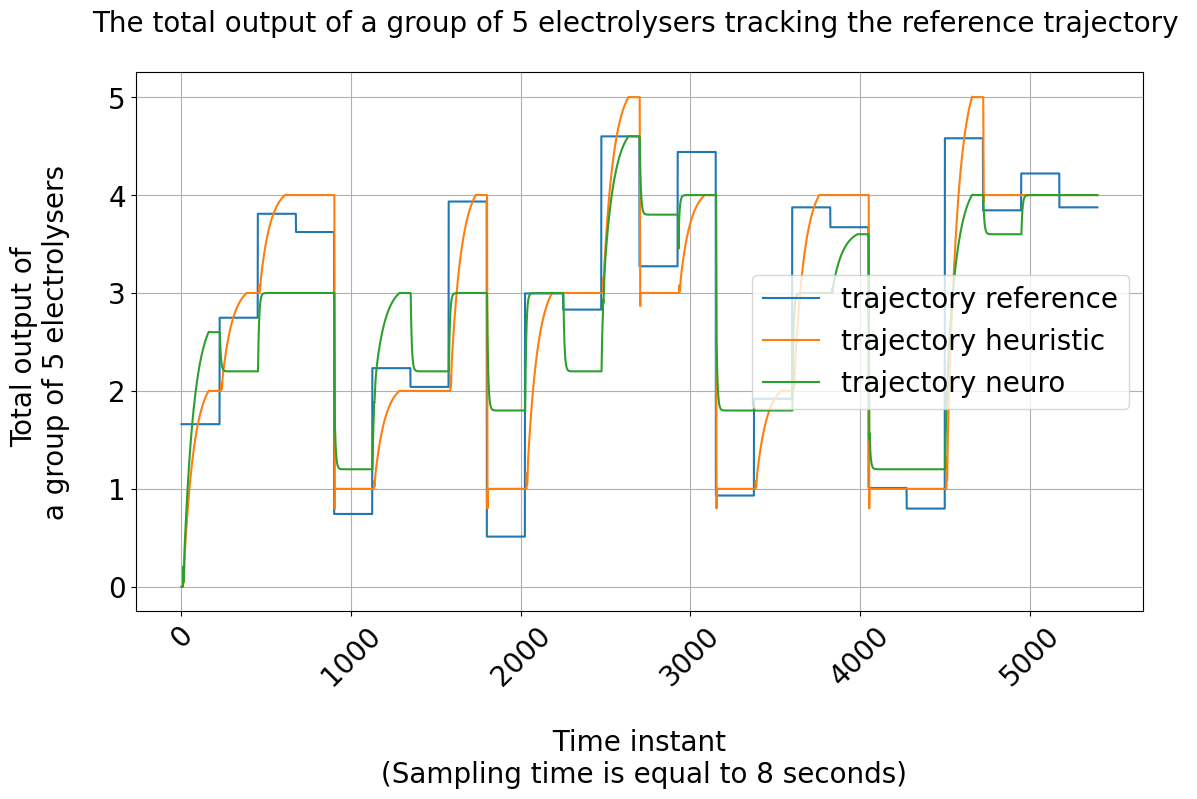

In [56]:
fig, ax = plt.subplots(figsize=(13, 7)) # (13, 6)
ax.set_title(f"The total output of a group of 5 electrolysers tracking the reference trajectory \n", fontsize=20)
plt.plot(trajectory_reference_heuristic, label='trajectory reference')
plt.plot(trajectory_heuristic, label='trajectory heuristic')
# plt.plot(trajectory_reference_neuro, label='trajectory_reference')
plt.plot(trajectory_neuro, label='trajectory neuro')
ax.set_xlabel(f'\n Time instant \n (Sampling time is equal to 8 seconds)', fontsize=20)
ax.set_ylabel(f'Total output of \n a group of 5 electrolysers \n', fontsize=20)
plt.legend(prop={'size': 20})
plt.grid(visible=True)
#  Устанавливаем интервал основных делений:
# ax.xaxis.set_major_locator(ticker.MultipleLocator(15 * 60))========
#  Устанавливаем интервал вспомогательных делений:
#ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
#  Тоже самое проделываем с делениями на оси "y":
# ax.yaxis.set_major_locator(ticker.MultipleLocator(1/2))===========
# ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))
#  Настраиваем вид основных тиков:
ax.tick_params(axis = 'x', labelrotation = 45) # axis = 'both',=============
ax.tick_params(axis = 'both', labelsize = 20)
plt.show()

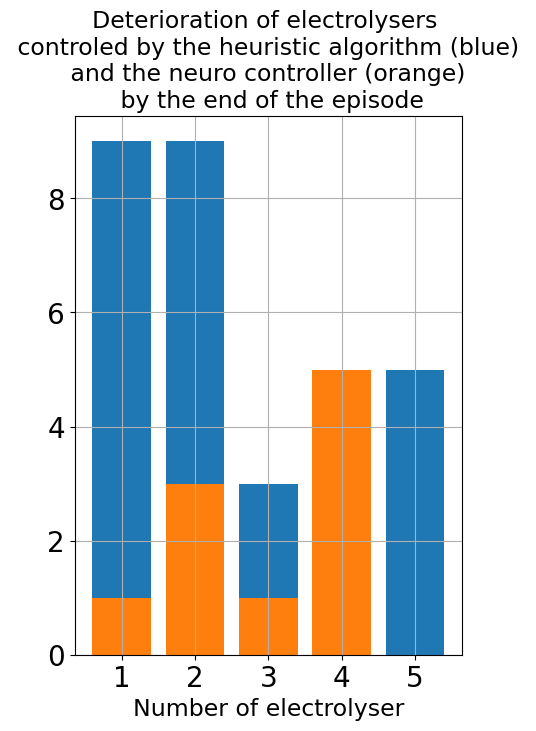

In [40]:
names = [1, 2, 3, 4, 5]
fig, ax = plt.subplots(figsize=(5, 7))
ax.set_title(f"Deterioration of electrolysers \n controled by the heuristic algorithm (blue) \n and the neuro controller (orange) \n by the end of the episode", fontsize=17)
plt.bar(names, group_deterioration_heuristic)
plt.bar(names, group_deterioration_neuro)
ax.set_xlabel('Number of electrolyser', fontsize=17)
plt.grid(visible=True)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.tick_params(axis='x', labelrotation=0)  # axis = 'both',
ax.tick_params(axis='both', labelsize=20)
plt.show()

# Assessment of controllers of the group of electrolysers

In [36]:
## init Reference
reference = ReferenceTrajectorySource(planing_horizon_in_seconds = HOURS_IN_PLANING_HORIZON * HOUR_TO_SEC,
                                      sampling_time_plan = SAMPLING_TIME_PLAN,
                                      sampling_time_plant = SAMPLING_TIME_PLANT,
                                      number_of_electrolysers = NUMBER_OF_ELECTROLYSERS,
                                      electrolyser_max_power = ELECTROLYSER_MAX_POWER,
                                      historical_data_path = "microgrid_data_analysis_processing/PM_tesla_PW_may22-sept22.csv", 
                                      simulation_time_in_seconds = SIMULATION_TIME)

/home/eduard/Desktop/projects/Electrolyser_control/experiments/ControlGroupElectrolysers/reference_trajectrory_source_model.py:85: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grid_power['grid_power'].clip(lower=None, upper=0, inplace=True)
/home/eduard/Desktop/projects/Electrolyser_control/experiments/ControlGroupElectrolysers/reference_trajectrory_source_model.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grid_power['grid_power'] = -grid_power['grid_power']
/home/eduard/Desktop/projects/Electrolyser_control/experiments/ControlGroupElectrolysers/referenc

In [37]:
## init assessment
assessment = ControlAssessment(sample_time_plant = SAMPLING_TIME_PLANT, electrolyser_max_power = ELECTROLYSER_MAX_POWER)

In [38]:
def assess_control_policy_on_one_day(policy,
                                     assessment,
                                     reference,
                                     steps_in_episode,
                                     number_of_electrolysers, 
                                     electrolyser_max_power, 
                                     sampling_time_plant, 
                                     sampling_time_plan, 
                                     sampling_time_control, 
                                     planing_horizon_in_seconds):
    assessment_data = {"RMSE": [], "deterioration_max": [], "deterioration_total": []}
    controller = Controller(policy=policy,
                            control_signal_dimension=number_of_electrolysers,
                            sampling_time_control=sampling_time_control)
    plant = GroupOfElectrolysers(number_of_electrolysers=number_of_electrolysers,
                                 sampling_time=sampling_time_plant)
    [trajectory_reference,
     trajectory,
     group_deterioration,
     control_strategy]  =  episode_simulation(plant, reference, controller, STEPS_IN_EPISODE)
    [Cost_episode,
     RMSE, J_y, J_u, J_d, MAE, SMAPE,
     unclaimed_energy, consumed_energy] = assessment.show_results(trajectory_reference,
                                                                  trajectory,
                                                                  group_deterioration,
                                                                  control_strategy)
    assessment_data["RMSE"] = RMSE
    assessment_data["deterioration_max"] = max(group_deterioration)
    assessment_data["deterioration_total"] = sum(group_deterioration)
    return assessment_data

In [39]:
import pandas as pd

In [40]:
assessment_data_list_heuristic = []
assessment_data_list_neuro = []

In [41]:
%%time
for d in range(1000):
    print(d)
    reference.prepare_plans()
    assessment_data_heuristic = assess_control_policy_on_one_day(policy_heuristic,
                                                       assessment,
                                                       reference,
                                                       STEPS_IN_EPISODE,
                                                       NUMBER_OF_ELECTROLYSERS, 
                                                       ELECTROLYSER_MAX_POWER, 
                                                       SAMPLING_TIME_PLANT, 
                                                       SAMPLING_TIME_PLAN, 
                                                       SAMPLING_TIME_CONTROL, 
                                                       HOURS_IN_PLANING_HORIZON * HOUR_TO_SEC)
    assessment_data_neuro = assess_control_policy_on_one_day(policy_neuro,
                                                       assessment,
                                                       reference,
                                                       STEPS_IN_EPISODE,
                                                       NUMBER_OF_ELECTROLYSERS,
                                                       ELECTROLYSER_MAX_POWER,
                                                       SAMPLING_TIME_PLANT,
                                                       SAMPLING_TIME_PLAN,
                                                       SAMPLING_TIME_CONTROL,
                                                       HOURS_IN_PLANING_HORIZON * HOUR_TO_SEC)
    assessment_data_list_heuristic.append(assessment_data_heuristic)
    assessment_data_list_neuro.append(assessment_data_neuro)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [42]:
assessment_df_heuristic = pd.DataFrame({"RMSE": [], "deterioration_max": [], "deterioration_total": []})
assessment_df_neuro = pd.DataFrame({"RMSE": [], "deterioration_max": [], "deterioration_total": []})

In [43]:
assessment_df_heuristic = assessment_df_heuristic.append(assessment_data_list_heuristic, ignore_index=True)
assessment_df_neuro = assessment_df_neuro.append(assessment_data_list_neuro, ignore_index=True)

/tmp/ipykernel_24726/435492858.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  assessment_df_heuristic = assessment_df_heuristic.append(assessment_data_list_heuristic, ignore_index=True)
/tmp/ipykernel_24726/435492858.py:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  assessment_df_neuro = assessment_df_neuro.append(assessment_data_list_neuro, ignore_index=True)


In [44]:
file_assessment_df = open('controllers_assessment/random_5_heuristic.pkl', 'wb')
pickle.dump(assessment_df_heuristic, file_assessment_df)
file_assessment_df.close()
file_assessment_df = open('controllers_assessment/random_5_neuro.pkl', 'wb')
pickle.dump(assessment_df_neuro, file_assessment_df)
file_assessment_df.close()

In [45]:
import pickle

In [46]:
file_assessment_df = open('controllers_assessment/random_5_heuristic.pkl', 'rb')
assessment_df_heuristic = pickle.load(file_assessment_df)
file_assessment_df.close()
file_assessment_df = open('controllers_assessment/random_5_neuro.pkl', 'rb')
assessment_df_neuro = pickle.load(file_assessment_df)
file_assessment_df.close()

In [47]:
assessment_df_heuristic

,RMSE,deterioration_max,deterioration_total
0,0.662437,10.0,38.0
1,0.625318,9.0,35.0
2,0.665870,9.0,40.0
3,0.432295,6.0,21.0
4,0.640465,10.0,44.0
...,...,...,...
995,0.618353,11.0,45.0
996,0.618354,10.0,37.0
997,0.639662,9.0,37.0
998,0.606030,11.0,42.0


In [48]:
assessment_df_neuro

,RMSE,deterioration_max,deterioration_total
0,0.687311,7.0,12.0
1,0.678894,10.0,17.0
2,0.658251,7.0,18.0
3,0.580667,6.0,15.0
4,0.794056,7.0,13.0
...,...,...,...
995,0.720873,8.0,23.0
996,0.658766,8.0,19.0
997,0.672663,6.0,14.0
998,0.766311,5.0,14.0


In [49]:
summary = pd.DataFrame({"RMSE": [], "deterioration_max": [], "deterioration_total": []})

In [50]:
summary["RMSE"] = [(np.mean(assessment_df_heuristic["RMSE"]), np.std(assessment_df_heuristic["RMSE"])),
                   (np.mean(assessment_df_neuro["RMSE"]), np.std(assessment_df_neuro["RMSE"]))]
summary["deterioration_max"] = [(np.mean(assessment_df_heuristic["deterioration_max"]),
                                 np.std(assessment_df_heuristic["deterioration_max"])),
                                (np.mean(assessment_df_neuro["deterioration_max"]),
                                 np.std(assessment_df_neuro["deterioration_max"]))]
summary["deterioration_total"] = [(np.mean(assessment_df_heuristic["deterioration_total"]),
                                   np.std(assessment_df_heuristic["deterioration_total"])),
                                  (np.mean(assessment_df_neuro["deterioration_total"]),
                                   np.std(assessment_df_neuro["deterioration_total"]))]

In [52]:
summary

,RMSE,deterioration_max,deterioration_total
0,"(0.638702529757465, 0.07495215844905204)","(10.279, 1.8507185091201572)","(37.902, 6.333908430029589)"
1,"(0.7295593640046614, 0.08898046481736466)","(6.774, 2.0675889340001907)","(14.678, 3.766207110608769)"


In [64]:
np.random.choice([7, 4, 3 ,2])

3

In [ ]:
# (0.638702529757465, 0.07495215844905204)
# (0.7295593640046614, 0.08898046481736466)
# (10.279, 1.8507185091201572)
# (6.774, 2.0675889340001907)
# (37.902, 6.333908430029589)
# (14.678, 3.766207110608769)